# Reconocimiento de actividades con redes recurrentes
Dataset UCI HAR (señales crudas de acelerómetro y giroscopio, licencia CC BY 4.0).
Comparamos CNN 1D contra RNN simple, después LSTM como mejora de la RNN, y por último un híbrido CNN + LSTM.

## 1. Configuración

In [1]:
import os, copy, json, time, random, zipfile, urllib.request, shutil
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn
import sklearn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

SEMILLA = 0         # semilla fija para que todo sea reproducible
EPOCHS = 60
PACIENCIA = 15
BATCH_SIZE = 64
LR = 1e-3
CLIP = 1.0
OUT = "resultados"
os.makedirs(OUT, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def fijar_semilla():
    random.seed(SEMILLA)
    np.random.seed(SEMILLA)
    torch.manual_seed(SEMILLA)
    torch.cuda.manual_seed_all(SEMILLA)
    torch.backends.cudnn.deterministic = True


print("torch", torch.__version__, "| device", DEVICE)

torch 2.11.0+cu128 | device cuda


## 2. Datos

In [2]:
URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
RAIZ = "UCI HAR Dataset"
if not os.path.isdir(RAIZ):
    urllib.request.urlretrieve(URL, "har.zip")
    zipfile.ZipFile("har.zip").extractall(".")
    if not os.path.isdir(RAIZ):
        zipfile.ZipFile("UCI HAR Dataset.zip").extractall(".")

CANALES = [f"{s}_{e}" for s in ["body_acc", "body_gyro", "total_acc"] for e in "xyz"]
CLASES = ["Caminar", "Subir escaleras", "Bajar escaleras", "Sentado", "Parado", "Acostado"]
leer = lambda ruta: pd.read_csv(ruta, sep=r"\s+", header=None).values


def cargar(split):
    base = f"{RAIZ}/{split}"
    X = np.stack([leer(f"{base}/Inertial Signals/{c}_{split}.txt") for c in CANALES], axis=-1)
    y = leer(f"{base}/y_{split}.txt").ravel() - 1
    sujetos = leer(f"{base}/subject_{split}.txt").ravel()
    return X.astype(np.float32), y, sujetos


X_full, y_full, suj_full = cargar("train")
X_test, y_test, _ = cargar("test")
print("train", X_full.shape, "| test", X_test.shape, "(ventanas, pasos, canales)")

train (7352, 128, 9) | test (2947, 128, 9) (ventanas, pasos, canales)


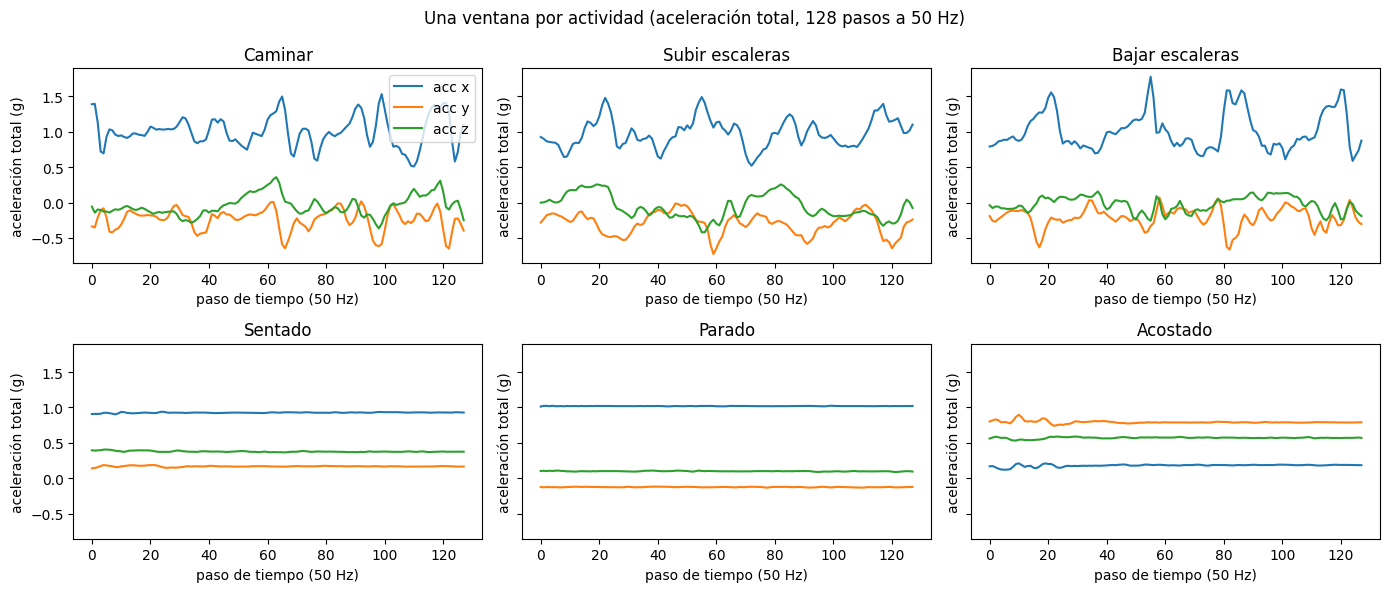

In [3]:
fig, ejes = plt.subplots(2, 3, figsize=(14, 6), sharey=True)
for c, ax in enumerate(ejes.ravel()):
    ax.plot(X_full[np.argmax(y_full == c), :, 6:9])
    ax.set_title(CLASES[c])
    ax.set_xlabel("paso de tiempo (50 Hz)")
    ax.set_ylabel("aceleración total (g)")
ejes[0, 0].legend(["acc x", "acc y", "acc z"])
plt.suptitle("Una ventana por actividad (aceleración total, 128 pasos a 50 Hz)")
plt.tight_layout()
plt.savefig(f"{OUT}/fig1_senales.png", dpi=150)
plt.show()

### Partición por persona y normalización
El test oficial ya tiene personas distintas. Validación también separa personas.
El scaler se ajusta solo con train y se aplica por canal.

In [4]:
idx_tr, idx_val = next(GroupShuffleSplit(test_size=0.2, random_state=0).split(X_full, y_full, suj_full))
X_tr, y_tr, X_val, y_val = X_full[idx_tr], y_full[idx_tr], X_full[idx_val], y_full[idx_val]
print("personas en validación:", sorted(set(suj_full[idx_val].tolist())))

# un solo scaler para los 9 canales: cada paso de tiempo es una muestra de 9 valores
scaler = StandardScaler().fit(X_tr.reshape(-1, 9))
norm = lambda X: scaler.transform(X.reshape(-1, 9)).reshape(X.shape).astype(np.float32)
loader = lambda X, y, mezclar=False: DataLoader(TensorDataset(torch.tensor(norm(X)), torch.tensor(y)),
                                               batch_size=BATCH_SIZE, shuffle=mezclar)
dl_tr, dl_val, dl_test = loader(X_tr, y_tr, True), loader(X_val, y_val), loader(X_test, y_test)

personas en validación: [3, 15, 19, 22, 30]


## 3. Baseline sin redes: regresión logística sobre la señal cruda

In [5]:
plano = lambda X: norm(X).reshape(len(X), -1)      # cada ventana pasa a ser un vector de 128 x 9 = 1152 valores
logreg = LogisticRegression(max_iter=3000).fit(plano(X_tr), y_tr)
pred = logreg.predict(plano(X_test))
BASELINE = {"acc_test": accuracy_score(y_test, pred), "f1_test": f1_score(y_test, pred, average="macro")}
print(BASELINE)

{'acc_test': 0.5826263997285375, 'f1_test': 0.554404797151776}


## 4. Modelos
Los cuatro tienen alrededor de 25 mil parámetros para que la comparación sea justa.

In [6]:
class CNN1D(nn.Module):
    # campo receptivo de la última convolución: 18 de 128 pasos
    # padding 2 con kernel 5 mantiene el largo: 128 + 2*2 - 5 + 1 = 128
    def __init__(self):
        super().__init__()
        self.red = nn.Sequential(
            nn.Conv1d(9, 32, 5, padding=2), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 48, 5, padding=2), nn.BatchNorm1d(48), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(48, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(64, 6))

    def forward(self, x):              # x: (batch, tiempo, canales)
        return self.red(x.transpose(1, 2))


class Recurrente(nn.Module):
    def __init__(self, celda, hidden):
        super().__init__()
        self.rnn = celda(9, hidden, batch_first=True)
        self.salida = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden, 6))

    def forward(self, x):
        estados, _ = self.rnn(x)
        return self.salida(estados[:, -1])   # el último estado resume la ventana


class CNNLSTM(nn.Module):
    # dos convoluciones sacan patrones locales, la LSTM recorre esa secuencia de patrones
    def __init__(self, hidden=43):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(9, 32, 5, padding=2), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 48, 5, padding=2), nn.BatchNorm1d(48), nn.ReLU(), nn.MaxPool1d(2))
        self.lstm = nn.LSTM(48, hidden, batch_first=True)
        self.salida = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden, 6))

    def forward(self, x):
        patrones = self.conv(x.transpose(1, 2)).transpose(1, 2)   # (batch, 64 pasos, 48 patrones)
        estados, _ = self.lstm(patrones)
        return self.salida(estados[:, -1])


MODELOS = {
    "CNN 1D": lambda: CNN1D(),
    "RNN simple": lambda: Recurrente(nn.RNN, 151),
    "LSTM": lambda: Recurrente(nn.LSTM, 74),
    "CNN + LSTM": lambda: CNNLSTM(),
}
for nombre, crear in MODELOS.items():
    print(f"{nombre:12s}", sum(p.numel() for p in crear().parameters()), "parámetros")

CNN 1D       25302 parámetros
RNN simple   25374 parámetros
LSTM         25610 parámetros
CNN + LSTM   25620 parámetros


## 5. Entrenamiento

In [7]:
def evaluar(modelo, dl):
    modelo.eval()
    with torch.no_grad():
        salidas = [(modelo(x.to(DEVICE)).cpu(), y) for x, y in dl]
    logits = torch.cat([s for s, _ in salidas])
    y = torch.cat([y for _, y in salidas])
    return nn.functional.cross_entropy(logits, y).item(), logits.argmax(1).numpy()


def entrenar(nombre):
    fijar_semilla()
    modelo = MODELOS[nombre]().to(DEVICE)
    opt = torch.optim.Adam(modelo.parameters(), lr=LR)
    hist = {"loss_tr": [], "loss_val": [], "acc_val": []}
    mejor, mejor_estado = float("inf"), None
    for ep in range(EPOCHS):
        modelo.train()
        perdidas = []
        for x, y in dl_tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            loss = nn.functional.cross_entropy(modelo(x), y)
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), CLIP)
            opt.step()
            perdidas.append(loss.item())
        loss_val, pred_val = evaluar(modelo, dl_val)
        hist["loss_tr"].append(np.mean(perdidas))
        hist["loss_val"].append(loss_val)
        hist["acc_val"].append(accuracy_score(y_val, pred_val))
        if loss_val < mejor:
            mejor, mejor_estado, mejor_ep = loss_val, copy.deepcopy(modelo.state_dict()), ep
        elif ep - mejor_ep >= PACIENCIA:
            break
    modelo.load_state_dict(mejor_estado)
    hist["mejor_epoca"] = mejor_ep + 1
    return modelo, hist

In [8]:
FINALES, HIST, FILAS = {}, {}, []
for nombre in MODELOS:
    t0 = time.time()
    FINALES[nombre], HIST[nombre] = entrenar(nombre)
    _, pred = evaluar(FINALES[nombre], dl_test)
    FILAS.append({"modelo": nombre, "mejor_epoca": HIST[nombre]["mejor_epoca"],
                  "epocas": len(HIST[nombre]["loss_val"]), "seg": round(time.time() - t0, 1),
                  "acc_val": HIST[nombre]["acc_val"][HIST[nombre]["mejor_epoca"] - 1], "acc_test": accuracy_score(y_test, pred),
                  "f1_test": f1_score(y_test, pred, average="macro")})
    print(FILAS[-1])

{'modelo': 'CNN 1D', 'mejor_epoca': 25, 'epocas': 40, 'seg': 23.2, 'acc_val': 0.9890363531448355, 'acc_test': 0.9416355615880556, 'f1_test': 0.942392030798804}
{'modelo': 'RNN simple', 'mejor_epoca': 29, 'epocas': 44, 'seg': 13.1, 'acc_val': 0.9734564339296018, 'acc_test': 0.8754665761791652, 'f1_test': 0.8764185676060877}
{'modelo': 'LSTM', 'mejor_epoca': 31, 'epocas': 46, 'seg': 14.5, 'acc_val': 0.9723023658395845, 'acc_test': 0.9134713267729895, 'f1_test': 0.9142514539050671}
{'modelo': 'CNN + LSTM', 'mejor_epoca': 22, 'epocas': 37, 'seg': 16.2, 'acc_val': 0.9890363531448355, 'acc_test': 0.9294197488971836, 'f1_test': 0.9302875569921909}


## 6. Curvas de entrenamiento

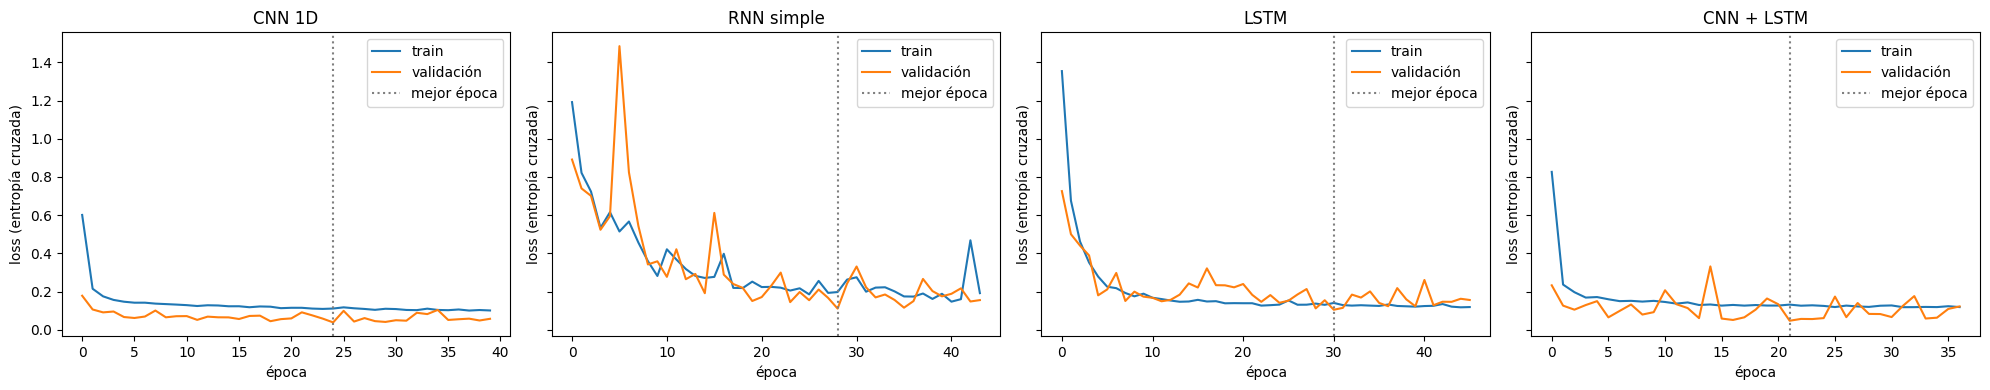

In [9]:
fig, ejes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
for ax, nombre in zip(ejes, MODELOS):
    ax.plot(HIST[nombre]["loss_tr"], label="train")
    ax.plot(HIST[nombre]["loss_val"], label="validación")
    ax.axvline(HIST[nombre]["mejor_epoca"] - 1, color="gray", ls=":", label="mejor época")
    ax.set_title(nombre)
    ax.set_xlabel("época")
    ax.set_ylabel("loss (entropía cruzada)")
    ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/fig2_curvas.png", dpi=150)
plt.show()

## 7. Resultados en test

In [10]:
tabla = pd.DataFrame(FILAS + [{"modelo": "LogReg (crudo)", **BASELINE}]).set_index("modelo")
tabla.round(4)

,mejor_epoca,epocas,seg,acc_val,acc_test,f1_test
modelo,,,,,,
CNN 1D,25.0,40.0,23.2,0.9890,0.9416,0.9424
RNN simple,29.0,44.0,13.1,0.9735,0.8755,0.8764
LSTM,31.0,46.0,14.5,0.9723,0.9135,0.9143
CNN + LSTM,22.0,37.0,16.2,0.9890,0.9294,0.9303
LogReg (crudo),NaN,NaN,NaN,NaN,0.5826,0.5544


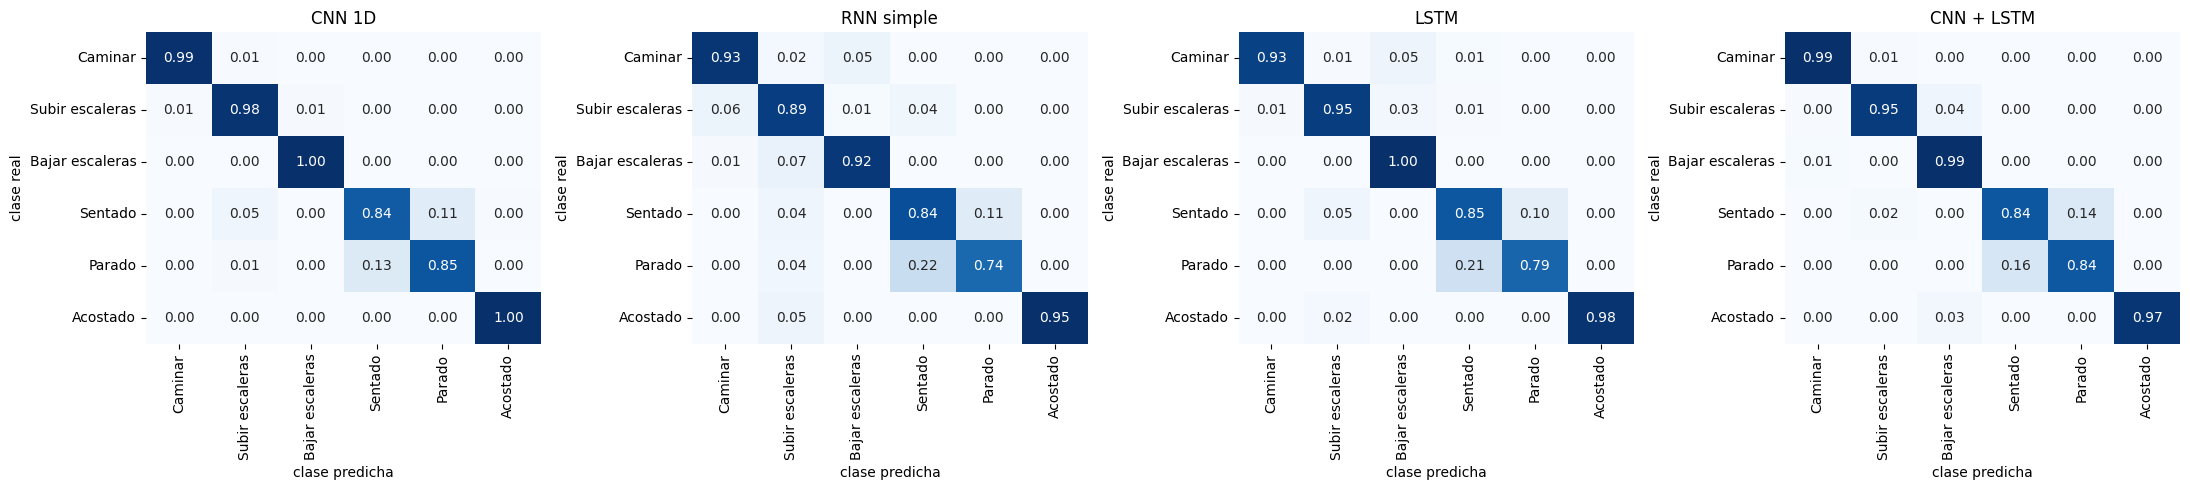

In [11]:
fig, ejes = plt.subplots(1, 4, figsize=(22, 5))
for ax, nombre in zip(ejes, MODELOS):
    cm = confusion_matrix(y_test, evaluar(FINALES[nombre], dl_test)[1], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=ax, xticklabels=CLASES, yticklabels=CLASES)
    ax.set_title(nombre)
    ax.set_xlabel("clase predicha")
    ax.set_ylabel("clase real")
plt.tight_layout()
plt.savefig(f"{OUT}/fig3_confusion.png", dpi=150)
plt.show()

## 8. ¿Usan el orden temporal?
Cortamos cada ventana en bloques y mezclamos el orden de los bloques. Bloque de 1 paso es mezclar todo.

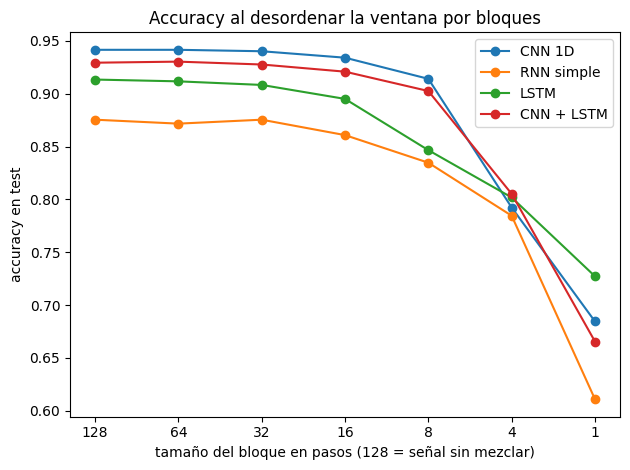

In [12]:
BLOQUES = [128, 64, 32, 16, 8, 4, 1]
rng = np.random.default_rng(SEMILLA)


def mezclar(X, tam):
    n = 128 // tam
    return np.stack([x.reshape(n, tam, 9)[rng.permutation(n)].reshape(128, 9) for x in X])


MEZCLA = {n: [] for n in MODELOS}
for b in BLOQUES:
    dl_mezclado = loader(mezclar(X_test, b), y_test)     # el mismo desorden para los cuatro modelos
    for n in MODELOS:
        MEZCLA[n].append(accuracy_score(y_test, evaluar(FINALES[n], dl_mezclado)[1]))
for n in MODELOS:
    plt.plot(range(len(BLOQUES)), MEZCLA[n], "o-", label=n)
plt.xticks(range(len(BLOQUES)), BLOQUES)
plt.xlabel("tamaño del bloque en pasos (128 = señal sin mezclar)")
plt.ylabel("accuracy en test")
plt.title("Accuracy al desordenar la ventana por bloques")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/fig4_mezcla.png", dpi=150)
plt.show()

## 9. Gradiente respecto a cada paso de tiempo
Si el gradiente se desvanece, los primeros pasos de la ventana casi no influyen en el aprendizaje.

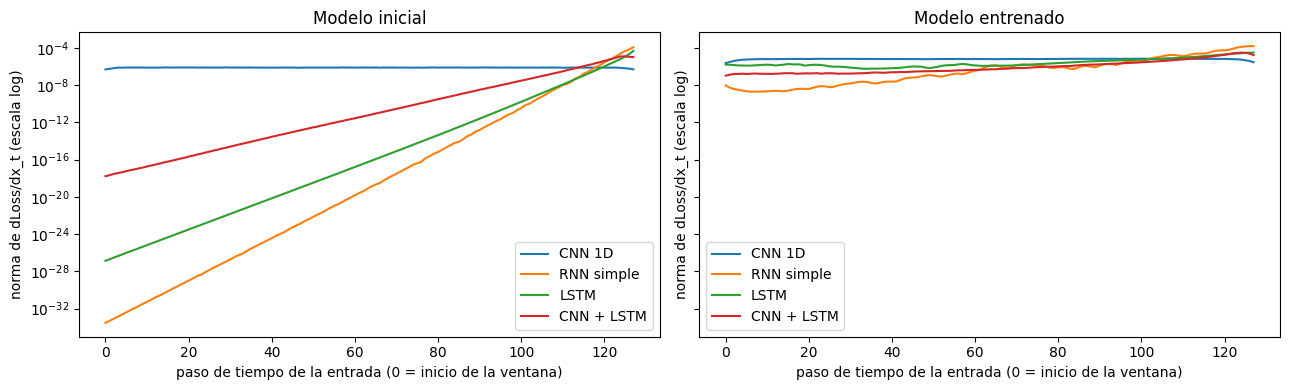

In [13]:
def gradiente_por_paso(modelo):
    m = copy.deepcopy(modelo).double().eval()       # float64 para ver valores muy chicos
    x = torch.tensor(norm(X_val[:512]), dtype=torch.float64, device=DEVICE, requires_grad=True)
    with torch.backends.cudnn.flags(enabled=False):
        nn.functional.cross_entropy(m(x), torch.tensor(y_val[:512], device=DEVICE)).backward()
    return x.grad.norm(dim=2).mean(0).cpu().numpy()


GRAD = {"inicial": {}, "entrenado": {}}
fig, ejes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, etapa in zip(ejes, GRAD):
    for n in MODELOS:
        if etapa == "inicial":
            fijar_semilla()
            modelo = MODELOS[n]().to(DEVICE)
        else:
            modelo = FINALES[n]
        GRAD[etapa][n] = gradiente_por_paso(modelo)
        ax.plot(GRAD[etapa][n], label=n)
    ax.set_yscale("log")
    ax.set_title(f"Modelo {etapa}")
    ax.set_xlabel("paso de tiempo de la entrada (0 = inicio de la ventana)")
    ax.set_ylabel("norma de dLoss/dx_t (escala log)")
    ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/fig5_gradiente.png", dpi=150)
plt.show()

## 10. Exportar resultados

In [14]:
json.dump({"baseline": BASELINE, "config": {"semilla": SEMILLA, "epochs": EPOCHS, "paciencia": PACIENCIA, "lr": LR, "batch": BATCH_SIZE},
           "corridas": FILAS, "mezcla": MEZCLA,
           "historias": {n: {k: np.array(v).tolist() for k, v in h.items()} for n, h in HIST.items()},
           "gradiente": {e: {n: g.tolist() for n, g in d.items()} for e, d in GRAD.items()},
           "versiones": {"python": os.sys.version.split()[0], "torch": torch.__version__, "numpy": np.__version__,
                         "pandas": pd.__version__, "sklearn": sklearn.__version__}},
          open(f"{OUT}/resultados.json", "w"), indent=1, default=float)
shutil.make_archive("resultados", "zip", OUT)
try:
    from google.colab import files
    files.download("resultados.zip")
except ImportError:
    print("resultados.zip generado")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>